In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
plt.style.use(['science','notebook'])

In [2]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [3]:
t_95 = 1.725
t_99 = 2.528

### Symmetric far wells along x, long time scales

In [4]:
N = 2500
n_jobs = 8
k = 100
taus = np.arange(20,420,20,dtype=int) #np.arange(50,1000,50,dtype=int)
alphas = np.linspace(0,1,300)
seeds = np.arange(20)

info_imbalances_X_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(seeds),len(taus),len(alphas)))

for iseed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y[iseed], info_imbalances_Y_to_X[iseed] = pickle.load( 
        open(f"./symmetric_energy_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb")
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y, correction=False)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X, correction=False)

Raw Information Imbalances:

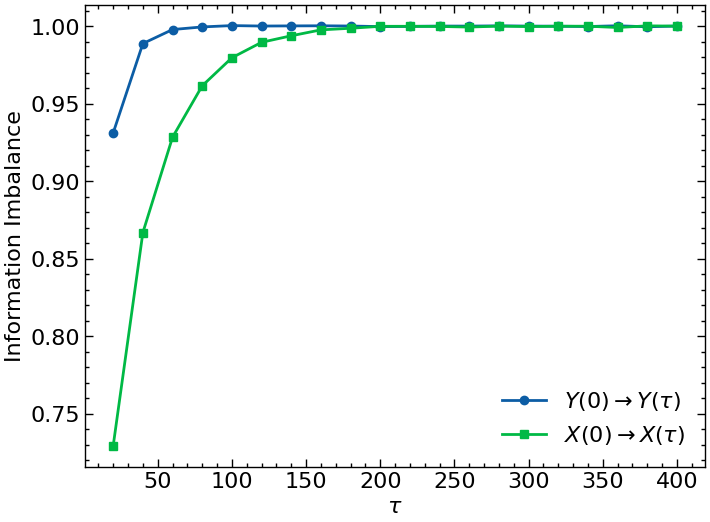

In [5]:
plt.plot(taus, info_imbalances_X_to_Y.mean(axis=0)[:,0], 'o-', label="$Y(0)\\rightarrow Y(\\tau)$")
plt.plot(taus, info_imbalances_Y_to_X.mean(axis=0)[:,0], 's-', label="$X(0)\\rightarrow X(\\tau)$")
plt.xlabel("$\\tau$")
plt.ylabel("Information Imbalance")
plt.legend()
plt.show()

Imbalance Gains:

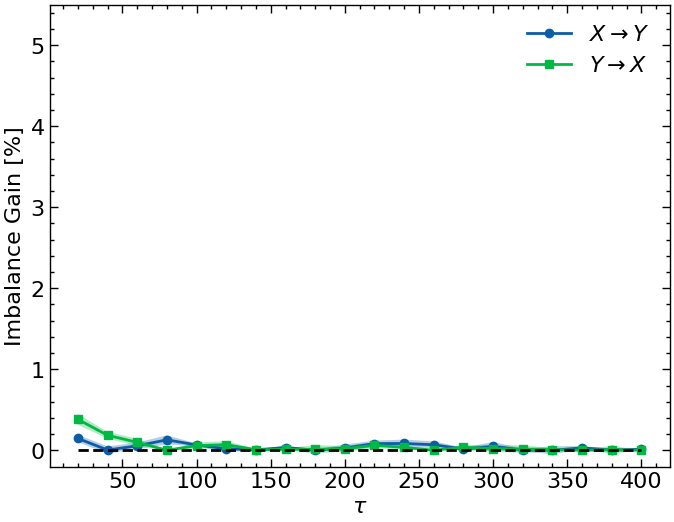

In [6]:
plt.plot(taus, IGs_X_to_Y, 'o-', label="$X\\rightarrow Y$")
plt.plot(taus, IGs_Y_to_X, 's-', label="$Y\\rightarrow X$")
plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.3)
plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.3)
plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("$\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.ylim([-0.2,5.5])
plt.show()

### Asymmetric far wells along x, long time scales

In [7]:
N = 2500
n_jobs = 8
k = 100
taus = np.arange(20,420,20,dtype=int) #np.arange(50,1000,50,dtype=int)
alphas = np.linspace(0,1,300)
seeds = np.arange(20)

info_imbalances_X_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(seeds),len(taus),len(alphas)))

for iseed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y[iseed], info_imbalances_Y_to_X[iseed] = pickle.load( 
        open(f"./asymmetric_energy_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb")
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y, correction=False)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X, correction=False)

Raw Information Imbalances:

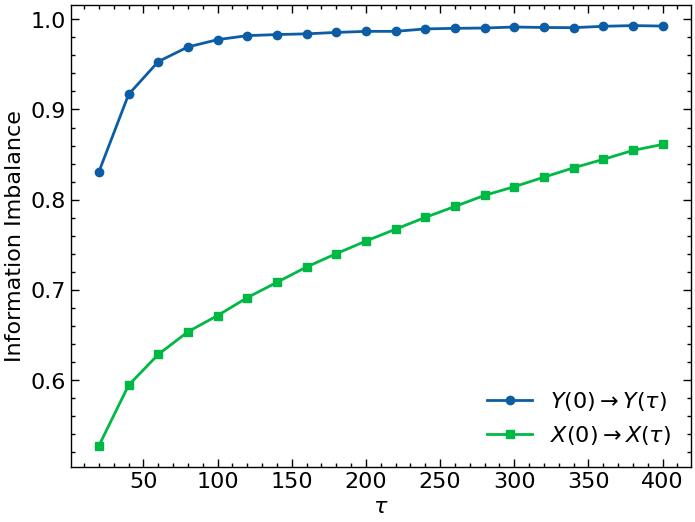

In [8]:
plt.plot(taus, info_imbalances_X_to_Y.mean(axis=0)[:,0], 'o-', label="$Y(0)\\rightarrow Y(\\tau)$")
plt.plot(taus, info_imbalances_Y_to_X.mean(axis=0)[:,0], 's-', label="$X(0)\\rightarrow X(\\tau)$")
plt.xlabel("$\\tau$")
plt.ylabel("Information Imbalance")
plt.legend()
plt.show()

Imbalance Gains:

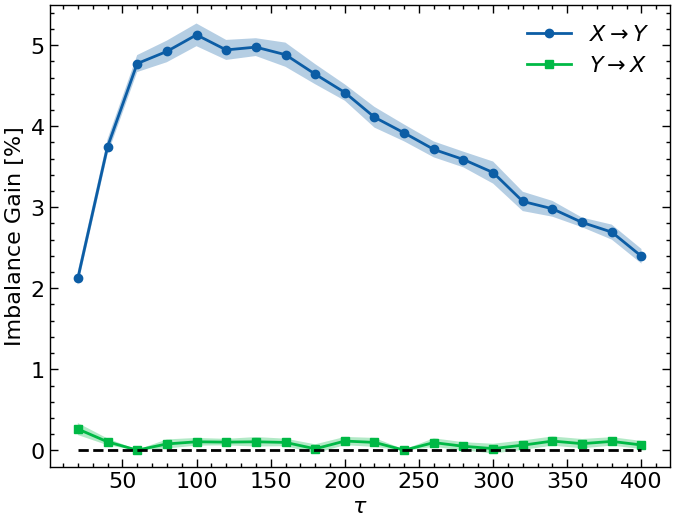

In [9]:
plt.plot(taus, IGs_X_to_Y, 'o-', label="$X\\rightarrow Y$")
plt.plot(taus, IGs_Y_to_X, 's-', label="$Y\\rightarrow X$")
plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.3)
plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.3)
plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("$\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.ylim([-0.2,5.5])
plt.show()

### Diagonal far wells, long time scales

In [4]:
N = 2500
n_jobs = 8
k = 100
taus = np.arange(20,420,20,dtype=int) #np.arange(50,1000,50,dtype=int)
alphas = np.linspace(0,1,300)
seeds = np.arange(20)

info_imbalances_X_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(seeds),len(taus),len(alphas)))

for iseed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y[iseed], info_imbalances_Y_to_X[iseed] = pickle.load( 
        open(f"./diagonal_wells_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb")
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y, correction=False)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X, correction=False)

Raw Information Imbalances:

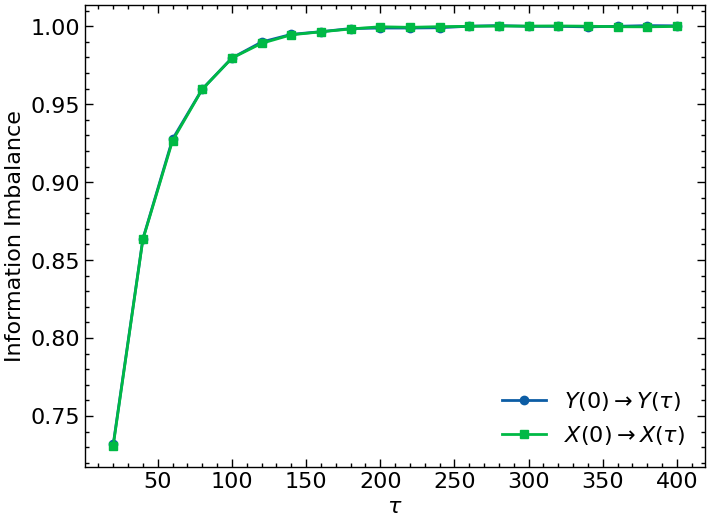

In [5]:
plt.plot(taus, info_imbalances_X_to_Y.mean(axis=0)[:,0], 'o-', label="$Y(0)\\rightarrow Y(\\tau)$")
plt.plot(taus, info_imbalances_Y_to_X.mean(axis=0)[:,0], 's-', label="$X(0)\\rightarrow X(\\tau)$")
plt.xlabel("$\\tau$")
plt.ylabel("Information Imbalance")
plt.legend()
plt.show()

Imbalance Gains:

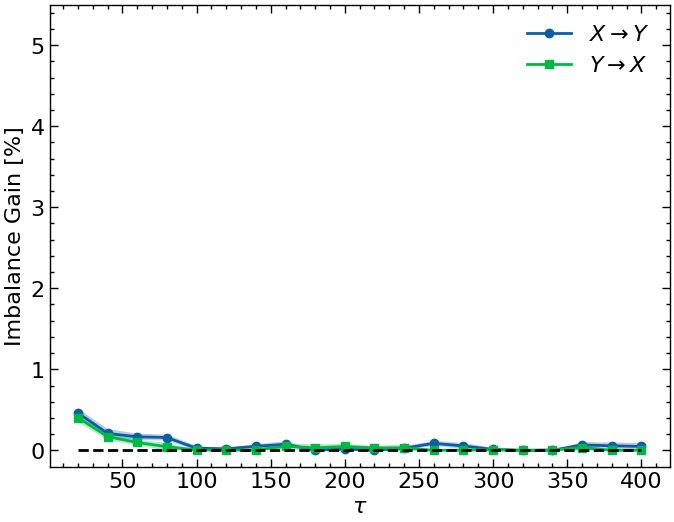

In [6]:
plt.plot(taus, IGs_X_to_Y, 'o-', label="$X\\rightarrow Y$")
plt.plot(taus, IGs_Y_to_X, 's-', label="$Y\\rightarrow X$")
plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.3)
plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.3)
plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("$\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.ylim([-0.2,5.5])
plt.show()

### 